## Quality Control and Validation of the Gene Expression Data

### **Purpose :** Check whether the gene-expression data are reliable enough for analysis by examining expression distributions, replicate consistency, sample relationships, unusual samples, and other potential quality problems

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Loading the expression matrix

In [2]:
DATA_PATH = Path(
    "../data/raw/GSE226105_rLog-Normalized_counts.csv"
)

df = pd.read_csv(DATA_PATH)

df = df.rename(
    columns={"Unnamed: 0": "gene_id"}
)

expression_values = df.drop(
    columns=["gene_id"]
)

### Loading our validated metadata

In [3]:
MANIFEST_PATH = Path(
    "../data/interim/sample_manifest.csv"
)

sample_manifest = pd.read_csv(MANIFEST_PATH)

### Checking our data

In [4]:
expression_values.shape

(28775, 57)

In [5]:
sample_manifest.shape

(57, 12)

In [6]:
set(expression_values.columns) == set(sample_manifest["matrix_column"])

True

#### The sample names in the expression matrix were compared with the sample names in the metadata table. 

#### All samples are present in both datasets, confirming that the expression data and sample metadata are correctly matched.


In [7]:
sample_qc = pd.DataFrame({
    "mean": expression_values.mean(),
    "median": expression_values.median(),
    "std": expression_values.std(),
    "min": expression_values.min(),
    "max": expression_values.max(),
})

sample_qc["q25"] = expression_values.quantile(0.25)
sample_qc["q75"] = expression_values.quantile(0.75)
sample_qc["iqr"] = sample_qc["q75"] - sample_qc["q25"]

sample_qc.head()

,mean,median,std,min,max,q25,q75,iqr
endpoint_COLD HL 1,5.291273,6.584800,4.683324,-2.423557,18.926072,0.0,9.131392,9.131392
endpoint_COLD HL 2,5.272989,6.547650,4.671550,-2.423551,18.962991,0.0,9.099724,9.099724
endpoint_COLD HL 3,5.262634,6.529711,4.659530,-2.423620,18.780046,0.0,9.076921,9.076921
endpoint_COLD 1,5.217002,6.502861,4.621249,-2.423620,18.949203,0.0,8.999503,8.999503
endpoint_COLD 2,5.187781,6.455127,4.601159,-2.423732,18.910195,0.0,8.950532,8.950532


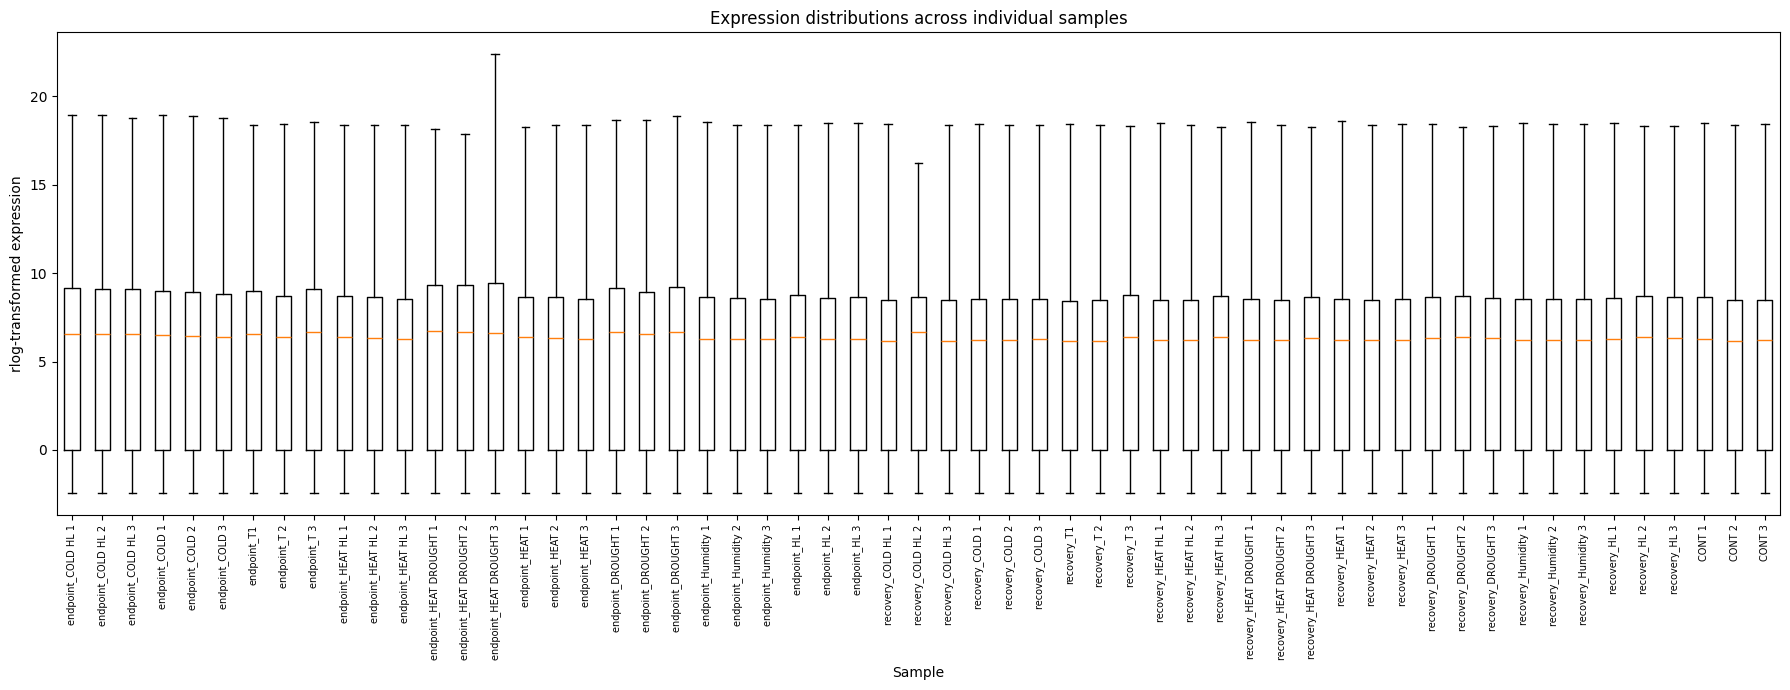

In [9]:
plt.figure(figsize=(18, 7))

plt.boxplot(
    [expression_values[col] for col in expression_values.columns],
    tick_labels=expression_values.columns,
    showfliers=False
)

plt.xticks(rotation=90, fontsize=7)
plt.ylabel("rlog-transformed expression")
plt.xlabel("Sample")
plt.title("Expression distributions across individual samples")

plt.tight_layout()
plt.show()

### Insight — Sample-wise expression distributions

#### The 57 samples display broadly comparable rlog-transformed expression distributions. 

#### Median expression levels and interquartile ranges are similar across endpoint, recovery, and control samples, with no sample showing an obvious overall shift or compression of its expression distribution. 

#### This provides preliminary evidence against a gross sample-level technical anomaly affecting the overall expression scale. 

#### Some variation is visible in the upper tails of individual samples, including differences within certain stress conditions, but these cannot be interpreted as technical outliers from distributional information alone because strong environmental treatments may legitimately alter subsets of highly expressed genes. 

#### Correlation analysis and PCA will be used next to examine replicate consistency and sample relationships more closely.

### Numerical Comparison of Sample Expression Distributions

#### Before correlation analysis, numerically summarize the differences between the 57 sample distributions.

In [10]:
sample_qc[
    ["mean", "median", "std", "iqr"]
].agg(["min", "max", "mean"])

,mean,median,std,iqr
min,4.890908,6.150726,4.345430,8.416390
max,5.434074,6.706243,4.776768,9.429376
mean,5.059044,6.355284,4.479539,8.717286


In [11]:
sample_qc.sort_values("median").head()

,mean,median,std,min,max,q25,q75,iqr
recovery_T1,4.890908,6.150726,4.356844,-2.423862,18.460594,0.0,8.416390,8.416390
CONT 2,4.924026,6.179460,4.382138,-2.423837,18.385383,0.0,8.481558,8.481558
recovery_COLD HL 3,4.925131,6.183950,4.384577,-2.423944,18.385383,0.0,8.481020,8.481020
recovery_COLD HL 1,4.913024,6.185620,4.369347,-2.423875,18.443940,0.0,8.460441,8.460441
recovery_T 2,4.932376,6.188889,4.388563,-2.423838,18.386999,0.0,8.494591,8.494591


In [12]:
sample_qc.sort_values("median").tail()

,mean,median,std,min,max,q25,q75,iqr
endpoint_T 3,5.266598,6.649230,4.622874,-2.423620,18.527964,0.0,9.082613,9.082613
endpoint_DROUGHT 3,5.334855,6.658634,4.680973,-2.423556,18.911993,0.0,9.219294,9.219294
recovery_COLD HL 2,5.071661,6.662274,4.345430,-2.422290,16.211415,0.0,8.627989,8.627989
endpoint_HEAT DROUGHT 2,5.395825,6.690506,4.731150,-2.423605,17.883613,0.0,9.349561,9.349561
endpoint_HEAT DROUGHT 1,5.391148,6.706243,4.728695,-2.423601,18.135070,0.0,9.328918,9.328918


#### Quantitative summaries confirm the visual impression from the sample-wise boxplots. 

#### Across the 57 samples, mean expression varies only from approximately 4.89 to 5.43 and median expression from 6.15 to 6.71, while standard deviations and interquartile ranges are similarly constrained. 

#### No sample exhibits an extreme global displacement in central tendency or dispersion. 

#### Some treatment-associated differences are present—for example, endpoint heat–drought samples occur among those with higher median expression—but these differences may represent genuine biological transcriptional responses rather than technical abnormalities. 

#### Global distributional similarity therefore provides no evidence of an obvious gross sample-level failure, although correlation analysis and PCA will be used next to examine replicate consistency and sample relationships more closely before drawing formal QC conclusions.

### Sample-to-Sample Correlation Analysis

#### We are trying to answer the question of whether samples with similar biological histories actually have similar gene-expression profiles.

### Calculating the 57 × 57 Pearson correlation matrix

In [17]:
sample_correlations = expression_values.corr(method="pearson")

#### Pearson correlation is used to measure the similarity between the overall expression profiles of each pair of samples across all genes.

> #### **Note — Pearson Correlation**
>
> #### Pearson correlation measures how closely two sets of numbers change together in a linear way. It produces a value between **−1 and +1**.
>
> #### A value close to **+1** means the two sets follow very similar patterns.
> #### A value close to **0** means there is little or no linear relationship between them.
> #### A value close to **−1** means they tend to move in opposite directions.
>
> #### In this dataset, each sample contains expression measurements for the same 28,775 genes. Pearson correlation compares two samples gene by gene and asks whether genes that have relatively high or low expression in one sample tend to show a similar pattern in the other.
>
> #### Biological replicates are expected to have relatively high correlations because they represent the same experimental condition. A replicate with a noticeably lower correlation than the others may therefore deserve further investigation.
>
> #### **Important:** A high correlation does not mean that two samples are identical, and correlation alone cannot determine whether a sample is biologically or technically valid. It is one piece of evidence used together with other quality-control analyses.

### Checking the correlation matrix shape

In [16]:
sample_correlations.shape

(57, 57)

##### The resulting Pearson correlation matrix has a shape of 57 × 57, confirming that correlations were calculated between all 57 samples in the expression dataset.

### Finding the minimum and maximum correlations between different samples

In [14]:
corr_values = sample_correlations.to_numpy()

corr_values[
    ~np.eye(corr_values.shape[0], dtype=bool)
].min(), corr_values[
    ~np.eye(corr_values.shape[0], dtype=bool)
].max()

(np.float64(0.9705012513465185), np.float64(0.9997070466341796))

#### r(min) = 0.9705 , r(max) = 0.9997

#### So every pair of samples is strongly positively correlated.

#### That is not surprising. All 57 samples are Arabidopsis rosette transcriptomes, and thousands of genes retain broadly similar relative expression across conditions. A drought-treated plant does not become an entirely different transcriptome from an Arabidopsis control.

#### But, a correlation of 0.97 versus 0.999 can still represent a meaningful difference in transcriptomics.

#### Because the entire matrix is compressed into a very high-correlation range, the relative differences within that range matter.

### Visualizing/examining the correlations using Heatmap

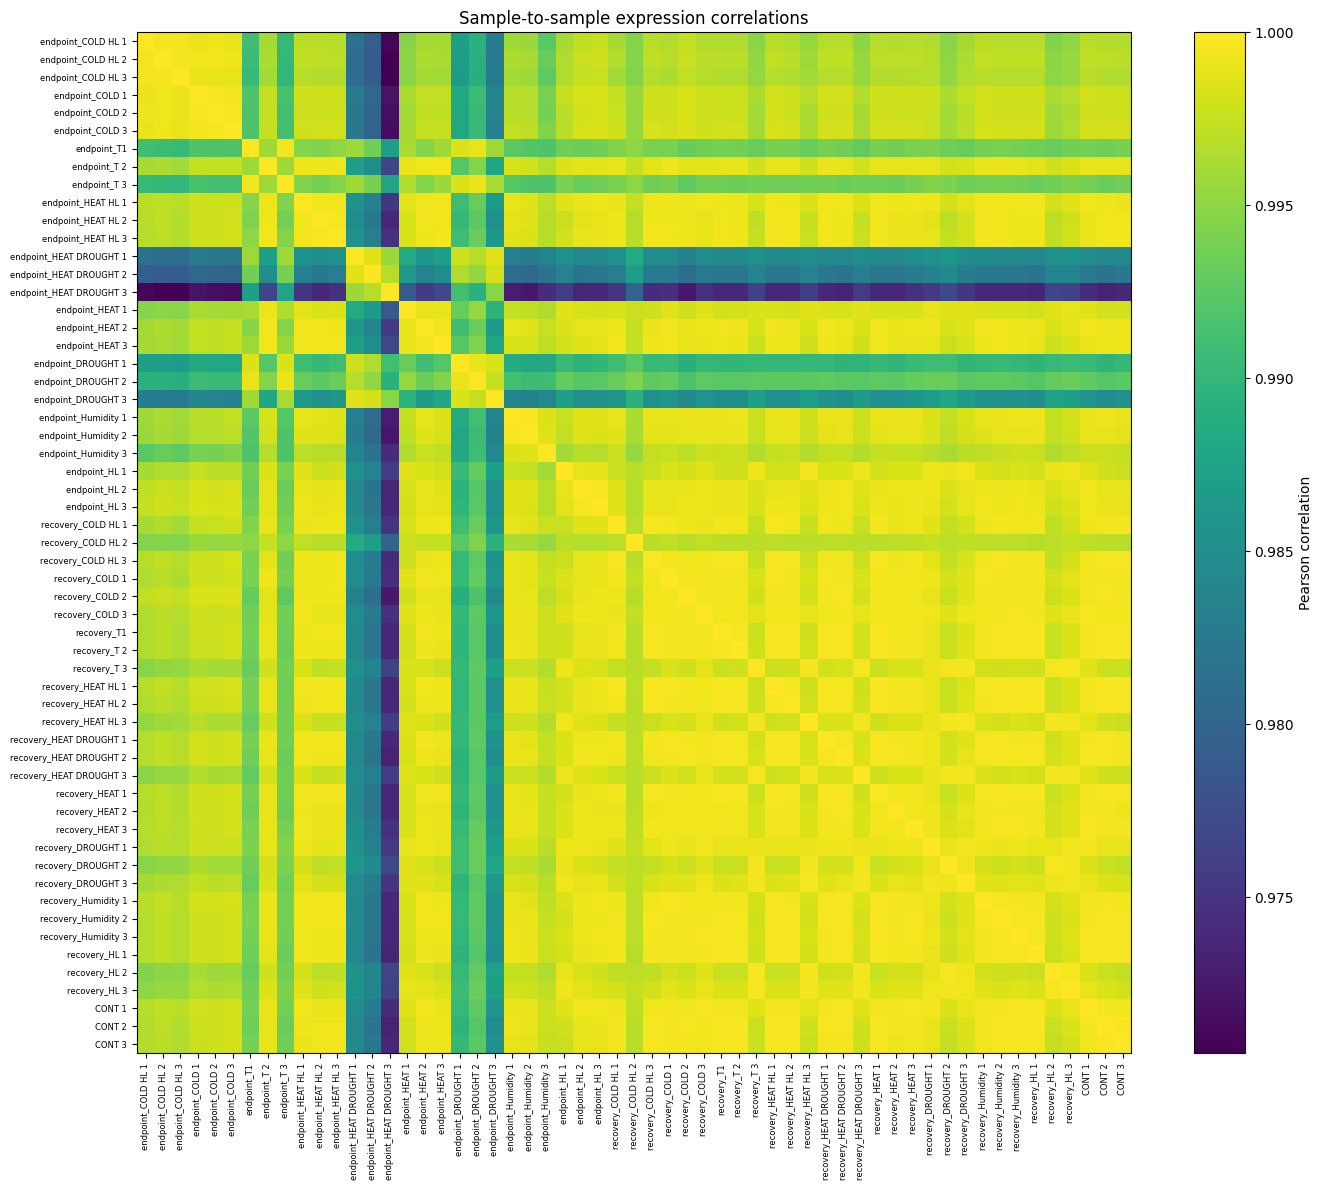

In [15]:
plt.figure(figsize=(14, 12))

plt.imshow(
    sample_correlations,
    aspect="auto"
)

plt.colorbar(label="Pearson correlation")

plt.xticks(
    range(len(sample_correlations.columns)),
    sample_correlations.columns,
    rotation=90,
    fontsize=6
)

plt.yticks(
    range(len(sample_correlations.index)),
    sample_correlations.index,
    fontsize=6
)

plt.title("Sample-to-sample expression correlations")
plt.tight_layout()
plt.show()

### **Insight — Preliminary sample-to-sample correlations**

#### Pearson correlations between the 57 samples are very high, ranging from approximately 0.9705 to 0.9997. This shows that the samples share broadly similar overall gene-expression patterns.

#### However, differences are still visible within this narrow range. Some endpoint stress samples show lower correlations with the rest of the dataset, particularly the heat–drought endpoint samples. `endpoint_HEAT DROUGHT 3` appears especially distinct.

#### This difference may represent a strong biological response to the combined stress treatment, but it is too early to classify the sample as an outlier. The biological replicates should be examined directly before making that conclusion. Recovery samples appear more similar to one another at this overall level.


### Checking for Invariant All-Zero Genes

#### Genes that have a value of zero in every sample do not vary across the experiment and cannot help distinguish one sample from another. 

#### The expression matrix is therefore checked for genes that are zero across all 57 samples before deciding whether any filtering is necessary.


### Removing Invariant All-Zero Genes

#### Genes that are zero across all 57 samples are excluded to create an expression matrix containing genes with a non-zero value in at least one sample. 
 
#### The sample correlations can then be recalculated using this filtered matrix.


In [18]:
informative_expression = expression_values.loc[
    (expression_values != 0).any(axis=1)
]

informative_expression.shape

(26118, 57)

### Recalculating the correlations

#### Pearson correlations are recalculated using the filtered expression matrix to determine whether removing invariant genes changes the overall sample relationships.

In [19]:
sample_correlations_filtered = informative_expression.corr(
    method="pearson"
)

In [20]:
corr_values_filtered = sample_correlations_filtered.to_numpy()

corr_values_filtered[
    ~np.eye(corr_values_filtered.shape[0], dtype=bool)
].min(), corr_values_filtered[
    ~np.eye(corr_values_filtered.shape[0], dtype=bool)
].max()

(np.float64(0.9660737949069862), np.float64(0.9996638335859261))

#### **Insight — Effect of removing invariant all-zero genes**

#### After excluding the 2,657 genes that were zero across all 57 samples, the minimum pairwise Pearson correlation decreased slightly from approximately 0.9705 to 0.9661, while the maximum correlation remained essentially unchanged at 0.9997.

#### The change is modest, indicating that removing invariant genes does not substantially alter the overall correlation structure between samples. The filtered matrix therefore provides a slightly more informative basis for examining sample relationships because it contains only genes with a non-zero value in at least one sample.

#### The strong correlations observed in the original analysis are therefore not dependent on the invariant all-zero genes.

#### In conclusion, removing genes that contained no expression information did not substantially change the relationships between the samples.

> #### **Note -** Invariant all-zero genes simply means "A gene whose value is 0 across all 57 samples"
>
> #### We care about this particularly because through our Pearson correlation analysis we trying to answer how similar are the overall gene-expression profiles of different samples

### Biological replicate consistency

#### Through this we are basically trying to understand whether the three samples belonging to the same biological condition agree with each other

#### This is much more informative than simply looking at the minimum correlation across all 57 samples, because now we're comparing samples that are actually supposed to resemble one another

In [ ]:
from itertools import combinations                                  # generate all unique pairs from a list

replicate_records = []

for (state, condition), group in sample_manifest.groupby(           # grouping the samples according to their experimental state and condition
    ["state", "condition"]                                          # then process one group at a time.
):
    samples = (
        group
        .sort_values("replicate")                                   # getting the sample names and putting them in replicate order
        ["matrix_column"]
        .tolist()
    )

    pairwise_corrs = []

    for sample_1, sample_2 in combinations(samples, 2):             # taking each unique replicate pair
        r = sample_correlations_filtered.loc[                       # looking up the Pearson correlation from the correlation matrix we already calculated
            sample_1, sample_2
        ]
        pairwise_corrs.append(r)                                    # values are stored here

    replicate_records.append({                                      # finally for each replication group we save :
        "state": state,
        "condition": condition,
        "pairwise_correlations": pairwise_corrs,
        "mean_replicate_correlation": np.mean(pairwise_corrs),      # the average correlation between its replicates
        "min_replicate_correlation": np.min(pairwise_corrs),        # the weakest replicate pair
        "max_replicate_correlation": np.max(pairwise_corrs),        # the strongest replicate pair
    })

replicate_qc = pd.DataFrame(replicate_records)                      # finally turning everything into a clean table

### Sorting experimental groups from lowest to highest mean replicate correlation

In [22]:
replicate_qc.sort_values(
    "mean_replicate_correlation"
)

,state,condition,pairwise_correlations,mean_replicate_correlation,min_replicate_correlation,max_replicate_correlation
6,endpoint,heat_drought_high_light,"[0.9951719777823754, 0.99940475236289, 0.99499...",0.996523,0.994993,0.999405
5,endpoint,heat_drought,"[0.998519926844692, 0.9948862237403887, 0.9962...",0.996567,0.994886,0.998520
11,recovery,cold_high_light,"[0.9967656640332602, 0.9994874711131089, 0.996...",0.997607,0.996566,0.999487
3,endpoint,drought,"[0.9990702928002461, 0.9980602866417558, 0.997...",0.998064,0.997061,0.999070
15,recovery,heat_drought_high_light,"[0.9995958680112329, 0.9973294795202219, 0.997...",0.998139,0.997329,0.999596
16,recovery,heat_high_light,"[0.9995938671681418, 0.9975308204709192, 0.997...",0.998277,0.997531,0.999594
18,recovery,high_light,"[0.9973400176236161, 0.9982021735097452, 0.999...",0.998352,0.997340,0.999514
14,recovery,heat_drought,"[0.999573207999317, 0.9979866182327642, 0.9981...",0.998573,0.997987,0.999573
8,endpoint,high_humidity,"[0.9996104720635233, 0.9981811316114904, 0.998...",0.998700,0.998181,0.999610
9,endpoint,high_light,"[0.9987980159065579, 0.9985689552592015, 0.999...",0.998954,0.998569,0.999494


### **Insight — Biological replicate consistency**

#### Biological replicates show very strong agreement across all 19 experimental groups. Mean within-group Pearson correlations range from approximately 0.9965 to above 0.9995, and even the lowest individual replicate correlation is approximately 0.9949.

#### No experimental group therefore shows an obvious replicate-level quality problem based on overall gene-expression similarity.

#### The endpoint heat–drought and heat–drought–high-light groups have slightly lower replicate correlations than many other conditions, suggesting somewhat greater variability under these combined stress treatments. However, their replicate correlations are still very high.

#### Importantly, `endpoint_HEAT DROUGHT 3`, which appeared more distinct in the broader sample correlation analysis, remains strongly correlated with its own biological replicates. This suggests that its difference from many other samples is more likely related to the heat–drought treatment than to an obvious technical failure.


### Within-Group vs Between-Group Sample Similarity

#### Replicate correlation tells us whether samples within the same experimental group are similar. 

#### As an additional check, each sample is now compared with its own biological replicates and with samples from other experimental groups.

#### For each sample, the mean correlation with its own group is compared with the mean correlation outside its group. 

#### A positive difference indicates that the sample is more similar to its own biological replicates than to samples from other experimental groups.


> #### **Note -** Ideally, within-group similarity > between-group similarity , for nearly every sample
>
> #### If one sample has within ≤ between , then that would be genuinely interesting and worthy of more inspection

In [23]:
sample_concordance_records = []

for _, row in sample_manifest.iterrows():

    sample = row["matrix_column"]
    state = row["state"]                                     # sample identity
    condition = row["condition"]

    same_group = sample_manifest[
        (sample_manifest["state"] == state) &                # finding samples with the same state and condition excluding the sample itself
        (sample_manifest["condition"] == condition) &
        (sample_manifest["matrix_column"] != sample)
    ]["matrix_column"].tolist()

    other_samples = sample_manifest[
        ~(
            (sample_manifest["state"] == state) &            # selecting everything that is not part of that exact experimental group
            (sample_manifest["condition"] == condition)
        )
    ]["matrix_column"].tolist()

    mean_within = (
        sample_correlations_filtered                        # retrieving the Pearson correlations between the current sample and its biological replicates
        .loc[sample, same_group]
        .mean()                                             # and calculating their average
    )

    mean_between = (
        sample_correlations_filtered
        .loc[sample, other_samples]                         # averaging coorelation with samples outside the group
        .mean()
    )

    sample_concordance_records.append({
        "sample": sample,
        "state": state,
        "condition": condition,
        "mean_within_group_correlation": mean_within,
        "mean_between_group_correlation": mean_between,
        "within_minus_between": mean_within - mean_between,
    })

sample_concordance = pd.DataFrame(
    sample_concordance_records
)

In [24]:
sample_concordance.sort_values(
    "within_minus_between"                                  # inspection step for the table we just created
).head(15)

,sample,state,condition,mean_within_group_correlation,mean_between_group_correlation,within_minus_between
7,endpoint_T 2,endpoint,heat_drought_high_light,0.995082,0.996801,-0.001718
51,recovery_HL 1,recovery,high_light,0.997771,0.996612,0.001159
28,recovery_COLD HL 2,recovery,cold_high_light,0.996666,0.995215,0.001451
29,recovery_COLD HL 3,recovery,cold_high_light,0.998027,0.996556,0.001470
27,recovery_COLD HL 1,recovery,cold_high_light,0.998127,0.996530,0.001597
35,recovery_T 3,recovery,heat_drought_high_light,0.997410,0.995803,0.001608
38,recovery_HEAT HL 3,recovery,heat_high_light,0.997618,0.995949,0.001669
33,recovery_T1,recovery,heat_drought_high_light,0.998463,0.996583,0.001880
36,recovery_HEAT HL 1,recovery,heat_high_light,0.998562,0.996650,0.001912
34,recovery_T 2,recovery,heat_drought_high_light,0.998543,0.996579,0.001964


### **Insight — Within-group vs between-group sample similarity**

#### For 56 of the 57 samples, the average correlation with their own biological replicates is higher than the average correlation with samples from other experimental groups. This shows that nearly every sample is more similar to its own group than to the rest of the experiment.

#### The only exception is `endpoint_T 2`, from the endpoint heat–drought–high-light treatment. Its mean correlation with its own replicates is approximately 0.9951, compared with approximately 0.9968 for samples outside its group. The difference is very small (approximately −0.0017), and the correlations themselves remain very high.

#### This does not provide enough evidence to classify `endpoint_T 2` as a problematic sample. Instead, it identifies the sample as worth examining more closely in the remaining quality-control analyses.


> #### **Thought :** The interesting thing is not that 0.9951 is a bad correlation. It's extremely high.
>
> #### The interesting thing is simply why this sample, on average, slightly more similar to samples outside its assigned experimental group than to the other two members of its own group.
>
> #### There could be perfectly legitimate biological reasons. Or there could be sample-specific variation. That part needs to be further investigated.

### Targeted Examination of `endpoint_T 2`

#### `endpoint_T 2` was the only sample whose mean correlation with its own biological replicates was slightly lower than its mean correlation with samples outside its experimental group. 

#### Its closest neighbouring samples are therefore examined individually to understand which expression profiles it most closely resembles.

### Finding which samples is `endpoint_T 2` actually most similar to

In [ ]:
target_sample = "endpoint_T 2"                        # finding the 15 nearest transcriptomic neighbours

(
    sample_correlations_filtered[target_sample]
    .drop(target_sample)
    .sort_values(ascending=False)
    .head(15)
)

endpoint_HEAT 2            0.999274
endpoint_HEAT HL 3         0.999248
endpoint_HEAT 3            0.999245
endpoint_HEAT HL 2         0.999177
recovery_COLD 1            0.999120
endpoint_HEAT HL 1         0.999087
recovery_Humidity 1        0.999064
recovery_HEAT DROUGHT 1    0.999055
recovery_Humidity 2        0.998951
endpoint_HEAT 1            0.998943
recovery_HEAT HL 1         0.998892
recovery_HEAT 1            0.998884
recovery_DROUGHT 1         0.998882
recovery_COLD HL 1         0.998857
recovery_HEAT HL 2         0.998855
Name: endpoint_T 2, dtype: float64

### Examining the correlations between `endpoint_T 2` and its two biological replicates

In [26]:
sample_correlations_filtered.loc[
    target_sample,
    ["endpoint_T1", "endpoint_T 3"]
]

endpoint_T1     0.995172
endpoint_T 3    0.994993
Name: endpoint_T 2, dtype: float64

### Comparing all three triple-stress replicates directly

In [27]:
sample_correlations_filtered.loc[
    ["endpoint_T1", "endpoint_T 2", "endpoint_T 3"],
    ["endpoint_T1", "endpoint_T 2", "endpoint_T 3"]
]

,endpoint_T1,endpoint_T 2,endpoint_T 3
endpoint_T1,1.000000,0.995172,0.999405
endpoint_T 2,0.995172,1.000000,0.994993
endpoint_T 3,0.999405,0.994993,1.000000


### **Insight — Targeted investigation of `endpoint_T 2`**

#### A closer examination of `endpoint_T 2` confirms that it behaves somewhat differently from its two biological replicates. Its correlations with `endpoint_T1` and `endpoint_T 3` are approximately 0.9952 and 0.9950, respectively. In comparison, `endpoint_T1` and `endpoint_T 3` correlate much more strongly with each other (approximately 0.9994).

#### The samples most strongly correlated with `endpoint_T 2` mainly belong to other endpoint stress conditions, particularly heat and heat–high-light treatments, with correlations of approximately 0.9992–0.9993. This suggests that `endpoint_T 2` has a different overall expression pattern from the other two samples in its assigned group.

#### The reason for this difference is not yet clear. It could reflect biological variation, differences in the treatment response, technical variation, or a problem with the sample metadata or assignment. `endpoint_T 2` will therefore be retained but examined further in the remaining quality-control analyses. Correlation evidence alone is not sufficient to remove the sample.

#### Right now, `endpoint_T` 2 is an interesting/suspicious sample requiring investigation, not a demonstrated bad sample.

#### In fact, the fact that it correlates extremely strongly (~0.9993) with coherent endpoint treatment samples rather than just behaving randomly is particularly interesting. Later multivariate analysis—especially PCA—can tell us whether T2 actually clusters away from T1/T3 and toward those other treatment groups.


### Principal Component Analysis (PCA) of Sample Relationships

> #### **Note -** PCA is used to examine the overall relationships between samples using expression patterns across thousands of genes at the same time. 
>
> #### This provides a visual way to see whether biological replicates cluster together, whether different treatments form distinct patterns, and whether any individual samples behave unusually.

### Preparing the Expression Matrix for PCA

#### PCA is performed using the 500 genes with the highest expression variance across the experiment. 

#### These genes contain more information about differences between samples than genes whose expression remains relatively constant.

#### The selected expression matrix is then transposed so that each row represents one of the 57 samples and each column represents one of the 500 selected genes, producing the sample × gene structure required for PCA.

In [28]:
gene_variance = informative_expression.var(axis=1)

top_variable_genes = (
    gene_variance
    .sort_values(ascending=False)
    .head(500)
    .index
)

pca_input = (
    informative_expression
    .loc[top_variable_genes]
    .T
)

pca_input.shape

(57, 500)

#### (57, 500) confirms that our PCA has been constructed in the intended shape

### Performing Principal Component Analysis

#### PCA is now applied to the prepared expression matrix to summarize the major patterns of variation between the 57 samples. 

#### Every sample lives in a space of 500 dimensions. PCA finds new directions through that space.

#### The analysis is reduced to the first two principal components (PC1 and PC2), which will allow the relationships between samples to be visualized in two dimensions.

#### **PC1 :** The direction explaining the largest amount of variation between samples.

#### **PC2 :** The next-largest independent direction of variation.

In [ ]:
from sklearn.decomposition import PCA                       # importing PCA from scikit-learn

pca = PCA(n_components=2)                                   # creating our PCA model, keeping the first two principal components

pca_scores = pca.fit_transform(pca_input)                   # fit + transform operations

### Creating a small PCA dataframe

In [30]:
pca_df = pd.DataFrame({
    "matrix_column": pca_input.index,
    "PC1": pca_scores[:, 0],
    "PC2": pca_scores[:, 1],
})

### Attaching our biological metadata

In [31]:
pca_df = pca_df.merge(
    sample_manifest,
    on="matrix_column",
    how="left"
)

#### The PCA coordinates for each sample are organized into a DataFrame and combined with the sample metadata. 

#### This allows the positions of samples in PCA space to be interpreted according to their experimental state, treatment condition, and biological replicate.

In [32]:
pca_df.shape

(57, 14)

In [33]:
pca.explained_variance_ratio_

array([0.80622646, 0.05973851])

#### `explained_variance_ratio_` gives us the proportion of total variation explained by each principal component.

#### PC1 explained approximately 80.62% of the variation, while PC2 explained approximately 5.97%.

#### **Insight — PCA preparation and explained variance**

#### PCA was performed using the 500 most variable genes across the 57 samples after removing the 2,657 invariant all-zero genes. The resulting PCA input contained 57 samples × 500 genes.

#### PC1 explained approximately 80.62% of the variation, while PC2 explained approximately 5.97%. Together, the first two principal components captured about 86.60% of the variation within the selected high-variance genes.

#### The large contribution of PC1 shows that one major pattern accounts for much of the variation between samples. However, the biological meaning of this pattern cannot yet be determined from the explained variance alone. The PCA plot will be examined next to determine how control, endpoint, recovery, and different stress-treatment samples are arranged along these components.

#### Because PCA was performed using the 500 most variable genes, these percentages describe the variation within this selected gene set rather than across the complete transcriptome.


### Inspecting the PCA table

In [34]:
pca_df[
    ["matrix_column", "state", "condition", "PC1", "PC2"]
].head()

,matrix_column,state,condition,PC1,PC2
0,endpoint_COLD HL 1,endpoint,cold_high_light,-6.516275,-6.974772
1,endpoint_COLD HL 2,endpoint,cold_high_light,-11.077447,-5.812534
2,endpoint_COLD HL 3,endpoint,cold_high_light,-10.864569,-1.743311
3,endpoint_COLD 1,endpoint,cold,-9.218734,-1.843752
4,endpoint_COLD 2,endpoint,cold,-8.772141,-6.060392


#### The PCA results were successfully combined with the sample metadata, preserving all 57 samples. 

#### Each sample now has corresponding PC1 and PC2 coordinates together with its experimental state and treatment condition, allowing the PCA structure to be interpreted biologically in the following visualization.

### Visualizing PCA by Experimental State

#### The first two principal components are plotted to examine the overall relationships among the 57 samples. 

#### Samples are grouped by experimental state to determine whether control, endpoint, and recovery samples show distinct patterns in PCA space.

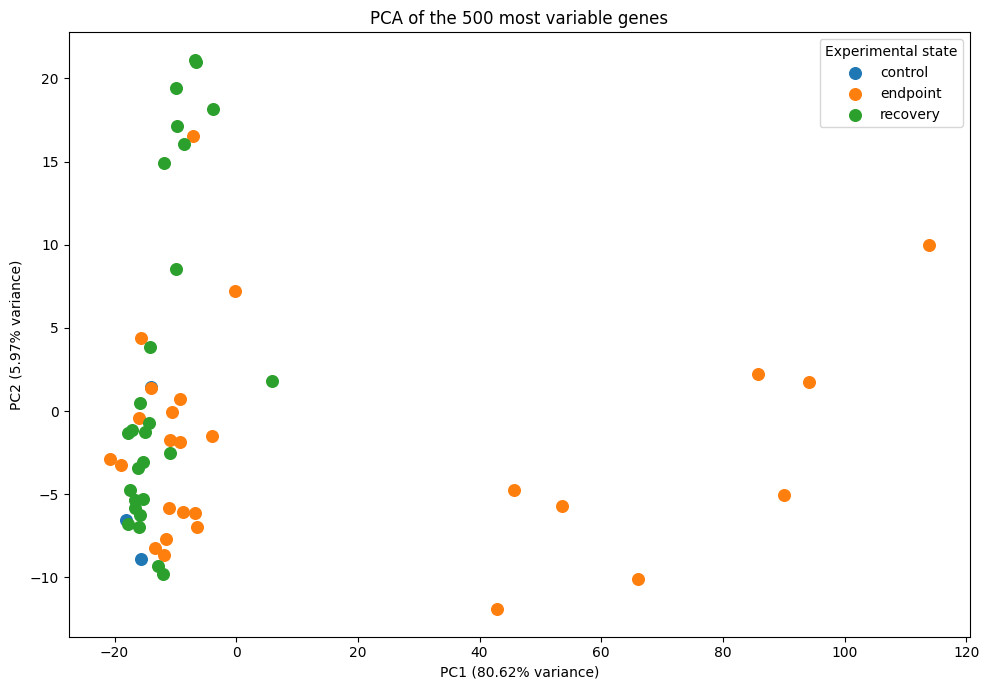

In [35]:
explained_variance = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(10, 7))

for state, group in pca_df.groupby("state"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=state,
        s=70
    )

plt.xlabel(
    f"PC1 ({explained_variance[0]:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]:.2f}% variance)"
)

plt.title(
    "PCA of the 500 most variable genes"
)

plt.legend(title="Experimental state")

plt.tight_layout()
plt.show()

### Labelling `endpoint_T2` in our PCA plot

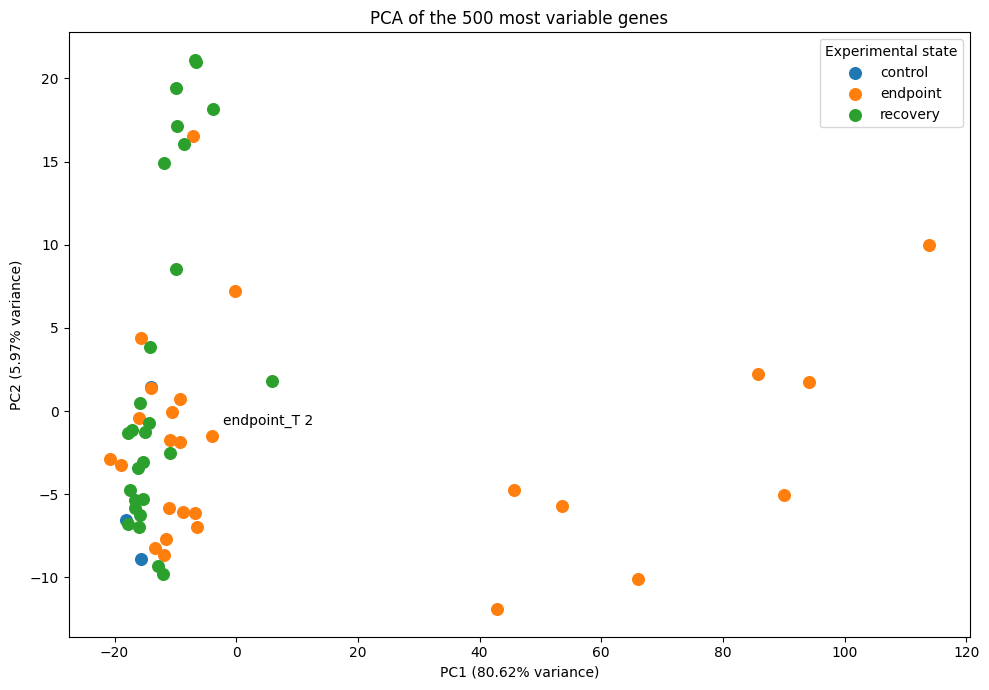

In [36]:
plt.figure(figsize=(10, 7))

for state, group in pca_df.groupby("state"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=state,
        s=70
    )

target = pca_df[
    pca_df["matrix_column"] == "endpoint_T 2"
].iloc[0]

plt.annotate(
    "endpoint_T 2",
    (target["PC1"], target["PC2"]),
    xytext=(8, 8),
    textcoords="offset points"
)

plt.xlabel(
    f"PC1 ({explained_variance[0]:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]:.2f}% variance)"
)

plt.title(
    "PCA of the 500 most variable genes"
)

plt.legend(title="Experimental state")

plt.tight_layout()
plt.show()

#### **Insight —** PCA by experimental state

#### PCA of the 500 most variable genes revealed a strongly dominant first principal component, with PC1 explaining approximately 80.62% of the selected-gene variance and PC2 explaining 5.97%.

#### The samples show clear structure according to experimental state. Control samples form a compact cluster at negative PC1 values, while endpoint samples are considerably more dispersed, with several extending strongly toward positive PC1 values. Many recovery samples occupy regions closer to the controls, although some recovery samples separate substantially along PC2.

#### This pattern is consistent with strong transcriptional changes during active stress followed by partial movement toward control-like expression patterns during recovery. However, the individual stress conditions must be examined before assigning a specific biological meaning to PC1 or interpreting the differences among recovery samples.

#### The previously flagged endpoint_T 2 sample lies within the central region of the PCA rather than appearing as a globally isolated sample. PCA therefore provides no evidence of a gross transcriptome-wide outlier, but its position relative to its own biological replicates and related stress conditions should be examined directly before drawing conclusions about its unusual correlation pattern.

### PCA by Stress Condition

#### The PCA is now visualized according to individual stress conditions to examine which treatments drive the major patterns of variation. 

#### The three endpoint heat–drought–high-light replicates are labelled separately to investigate the previously flagged `endpoint_T 2` sample in relation to its biological replicates

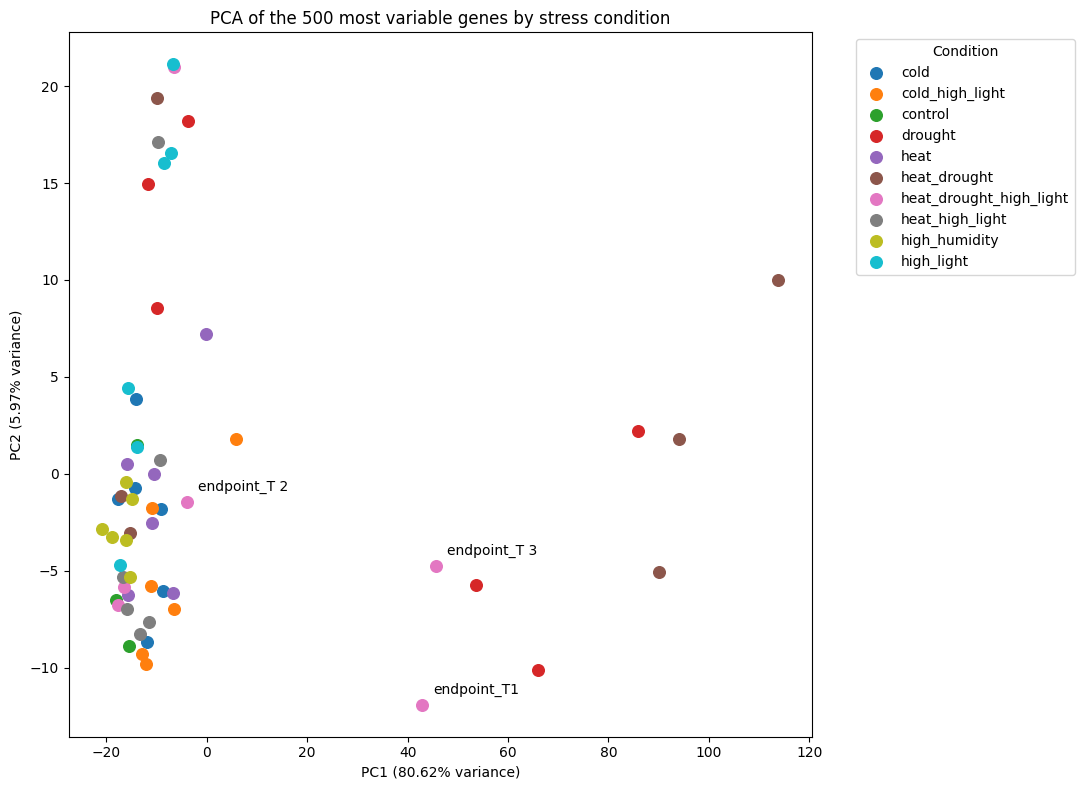

In [37]:
plt.figure(figsize=(11, 8))

for condition, group in pca_df.groupby("condition"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=condition,
        s=70
    )

for sample_name in [
    "endpoint_T1",
    "endpoint_T 2",
    "endpoint_T 3"
]:
    target = pca_df[
        pca_df["matrix_column"] == sample_name
    ].iloc[0]

    plt.annotate(
        sample_name,
        (target["PC1"], target["PC2"]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel(
    f"PC1 ({explained_variance[0]:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]:.2f}% variance)"
)

plt.title(
    "PCA of the 500 most variable genes by stress condition"
)

plt.legend(
    title="Condition",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### **Observation :**

#### The three endpoint triple-stress replicates are: `endpoint_T1` `endpoint_T 2` `endpoint_T 3` , and they do not occupy the same region of PCA space.

#### endpoint_T1 and endpoint_T 3 are both strongly displaced toward positive PC1:

#### endpoint_T1 ≈ PC1 42, PC2 −12

#### endpoint_T 3 ≈ PC1 45, PC2 −5

#### whereas:

#### endpoint_T 2 ≈ PC1 −4, PC2 −1

#### So the most important pattern is:

#### T1, T3 ---> strong positive PC1 , while,

#### T2 ---> central/ negative-PC1 region

#### That is a large multivariate displacement, not merely a tiny visual difference.

#### Also, earlier we observed that PC1 = 80.62% of the variance among the 500 most variable genes

#### So T2 differs from T1/T3 along the dominant expression axis of this dataset

#### This conclusion also agrees with our previous correlation analysis


### **Insight —** PCA by stress condition and investigation of the triple-stress replicates

#### Coloring the PCA by stress condition reveals substantial condition-dependent structure in the expression data. Several endpoint samples from drought, heat–drought, and heat–drought–high-light treatments extend strongly toward positive PC1 values, suggesting that the dominant principal component captures an important part of the transcriptional response to these stress conditions. The specific biological meaning of PC1, however, cannot yet be determined from sample positions alone.

#### The three endpoint heat–drought–high-light replicates show a particularly notable pattern. `endpoint_T1` and `endpoint_T 3` occupy a similar positive-PC1 region, whereas `endpoint_T 2` lies much closer to the central sample cluster. This separation occurs primarily along PC1, which explains approximately 80.62% of the variance in the 500 genes used for PCA.

#### This result is consistent with the earlier correlation analysis, in which `endpoint_T1` and `endpoint_T 3` correlated much more strongly with each other than either did with `endpoint_T 2`. Two different analyses therefore identify unusual behavior in `endpoint_T 2` relative to its assigned biological replicates.

#### However, `endpoint_T 2` is not globally isolated from the rest of the dataset. It is therefore retained at this stage and flagged for further investigation rather than excluded. Possible explanations include biological variation in treatment response, technical variation, or a sample/metadata assignment issue.

### Focused Examination of Endpoint Samples

#### Because the largest separations in the PCA are observed among endpoint samples, the PCA results are filtered to the endpoint state for closer examination of treatment-specific patterns and replicate relationships.

In [38]:
endpoint_pca = pca_df[
    pca_df["state"] == "endpoint"
].copy()

endpoint_pca.shape

(27, 14)

#### 9 conditions x 3 replicates = 27 . So, this one is Checked.

### Focused PCA of Endpoint Samples

#### To examine treatment-specific structure more clearly, the PCA visualization is restricted to endpoint samples. 

#### This removes control and recovery samples from the display while retaining the PC1 and PC2 coordinates calculated from the full dataset, allowing endpoint stress conditions and replicate relationships to be inspected more closely.

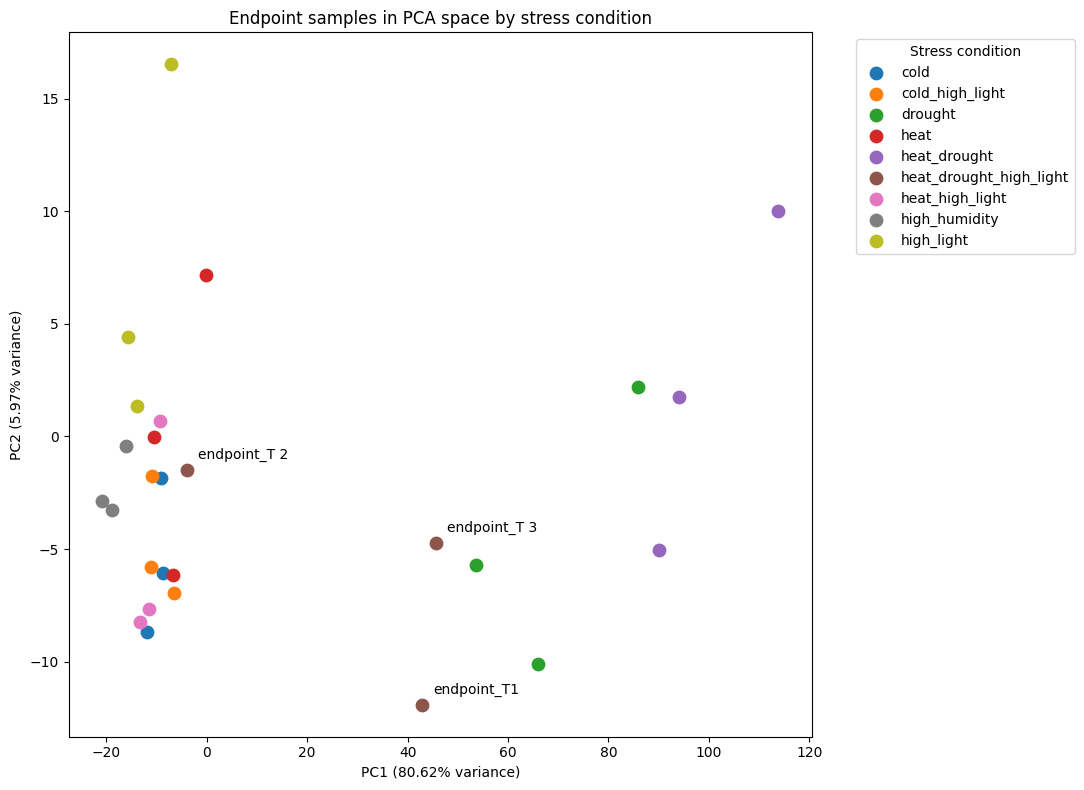

In [39]:
plt.figure(figsize=(11, 8))

for condition, group in endpoint_pca.groupby("condition"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=condition,
        s=80
    )

for sample_name in [
    "endpoint_T1",
    "endpoint_T 2",
    "endpoint_T 3"
]:
    target = endpoint_pca[
        endpoint_pca["matrix_column"] == sample_name
    ].iloc[0]

    plt.annotate(
        sample_name,
        (target["PC1"], target["PC2"]),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel(
    f"PC1 ({explained_variance[0]:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({explained_variance[1]:.2f}% variance)"
)

plt.title(
    "Endpoint samples in PCA space by stress condition"
)

plt.legend(
    title="Stress condition",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### **Insight —** Endpoint-only PCA and the atypical triple-stress replicate

#### Restricting the existing PCA coordinates to the 27 endpoint samples confirms that the unusual position of `endpoint_T 2` is not simply a consequence of the broader endpoint-versus-recovery structure of the experiment. 

#### `endpoint_T1` and `endpoint_T 3` both occupy strongly positive-PC1 regions, whereas `endpoint_T 2` remains within the dense low-PC1 cluster containing several other endpoint stress conditions.

#### Because PC1 explains approximately 80.62% of the variance in the 500 most variable genes, the main separation between endpoint_T 2 and its assigned biological replicates occurs along the dominant transcriptomic axis. 

#### Although T1 and T3 differ somewhat along PC2, both show a much stronger positive-PC1 displacement than T2.

#### This pattern indicates that `endpoint_T 2` has a substantially different transcriptomic response from the other two heat–drought–high-light endpoint replicates. 

#### However, the sample remains embedded among other biologically plausible endpoint transcriptomes rather than appearing as an isolated global outlier. It is therefore retained and flagged for further investigation rather than excluded on the basis of PCA alone.

### Quantitative PCA-space separation of the triple-stress replicates

#### This will let us say numerically how far T2 is from T1/T3, and which endpoint states it actually occupies closest to in the dominant PCA space.

In [40]:
from sklearn.metrics import pairwise_distances

endpoint_coords = endpoint_pca.set_index(
    "matrix_column"
)[["PC1", "PC2"]]

pca_distances = pd.DataFrame(
    pairwise_distances(endpoint_coords),
    index=endpoint_coords.index,
    columns=endpoint_coords.index
)

In [41]:
(
    pca_distances["endpoint_T 2"]
    .drop("endpoint_T 2")
    .sort_values()
    .head(10)
)

matrix_column
endpoint_COLD 1       5.227839
endpoint_HEAT 3       5.401143
endpoint_HEAT HL 1    5.687870
endpoint_COLD HL 1    6.045301
endpoint_COLD 2       6.614438
endpoint_HEAT 2       6.664016
endpoint_COLD HL 3    6.865938
endpoint_COLD HL 2    8.296933
endpoint_HEAT 1       9.486554
endpoint_HEAT HL 3    9.702141
Name: endpoint_T 2, dtype: float64

In [42]:
pca_distances.loc[
    ["endpoint_T1", "endpoint_T 2", "endpoint_T 3"],
    ["endpoint_T1", "endpoint_T 2", "endpoint_T 3"]
]

matrix_column,endpoint_T1,endpoint_T 2,endpoint_T 3
matrix_column,,,
endpoint_T1,6.743496e-07,48.016908,7.679263
endpoint_T 2,4.801691e+01,0.000000,49.735516
endpoint_T 3,7.679263e+00,49.735516,0.000000


### **Insight —** Quantitative PCA-space separation of the triple-stress replicates

#### Euclidean distances in the existing PC1–PC2 space quantitatively confirm the unusual position of endpoint_T 2. 

#### The two other heat–drought–high-light endpoint replicates, endpoint_T1 and endpoint_T 3, are separated by only approximately 7.68 PCA units, whereas endpoint_T 2 is approximately 48.02 units from T1 and 49.74 units from T3. 

#### Thus, T2 is more than six times farther from either assigned replicate than T1 and T3 are from each other in the first two principal components.

#### The nearest endpoint neighbours of endpoint_T 2 instead belong to several other stress conditions, including heat, heat–high-light, cold, and cold–high-light. This places T2 within the broader low-PC1 endpoint cluster rather than near the strongly displaced triple-stress replicates.

#### This quantitative result is consistent with the earlier correlation and PCA analyses and further supports the conclusion that endpoint_T 2 occupies a substantially different transcriptomic state from the other two triple-stress replicates. 

#### Because these distances are calculated only in the first two PCA dimensions, they summarize the dominant variation rather than the complete expression space. 

#### However, PC1 and PC2 together capture approximately 86.6% of the variance in the 500 selected genes, making this two-dimensional representation highly informative for the QC assessment.

#### T2 is investigated enough with pairwise correlation + replicate concordance + nearest neighbours + PCA + PCA distance.

#### The next independent QC method will be focused on hierarchical sample clustering using the 500 most variable genes

### Hierarchical Clustering of Transcriptomic Samples

#### As a complementary assessment of sample relationships, hierarchical clustering is performed using the 500 most variable genes. 

#### Correlation distance measures similarity between sample expression profiles, while average-linkage clustering groups samples according to these relationships. 

#### The resulting dendrogram provides an additional way to examine replicate consistency, treatment-related structure, and unexpected sample groupings without reducing the data to the first two principal components.

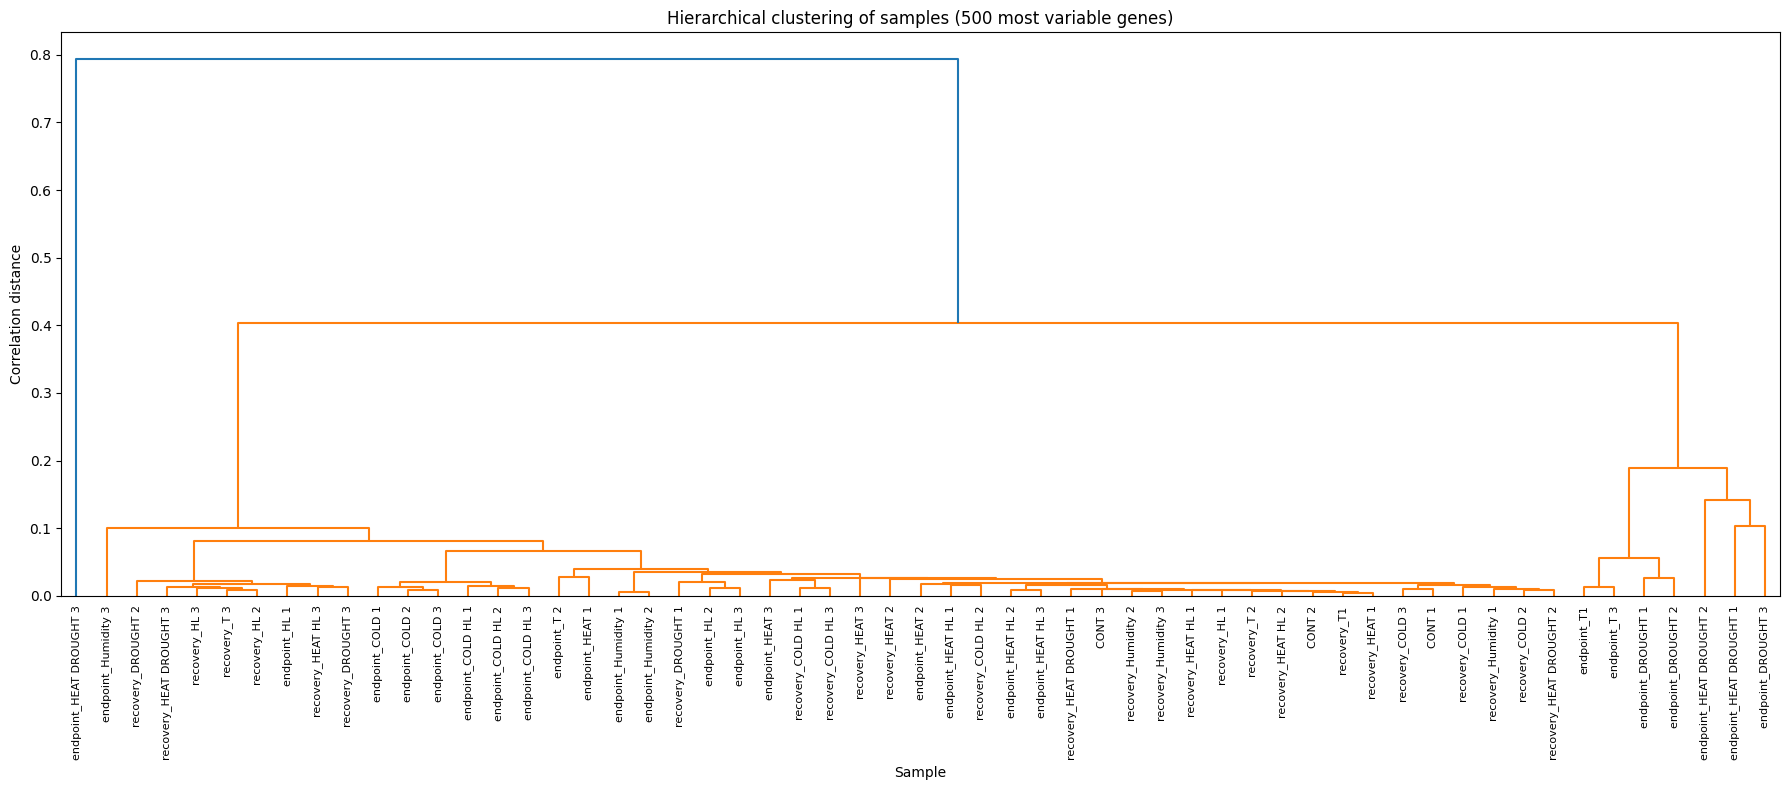

In [43]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

correlation_distance = pdist(
    pca_input,
    metric="correlation"
)

linkage_matrix = linkage(
    correlation_distance,
    method="average"
)

plt.figure(figsize=(18, 8))

dendrogram(
    linkage_matrix,
    labels=pca_input.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=8
)

plt.title("Hierarchical clustering of samples (500 most variable genes)")
plt.xlabel("Sample")
plt.ylabel("Correlation distance")

plt.tight_layout()
plt.show()

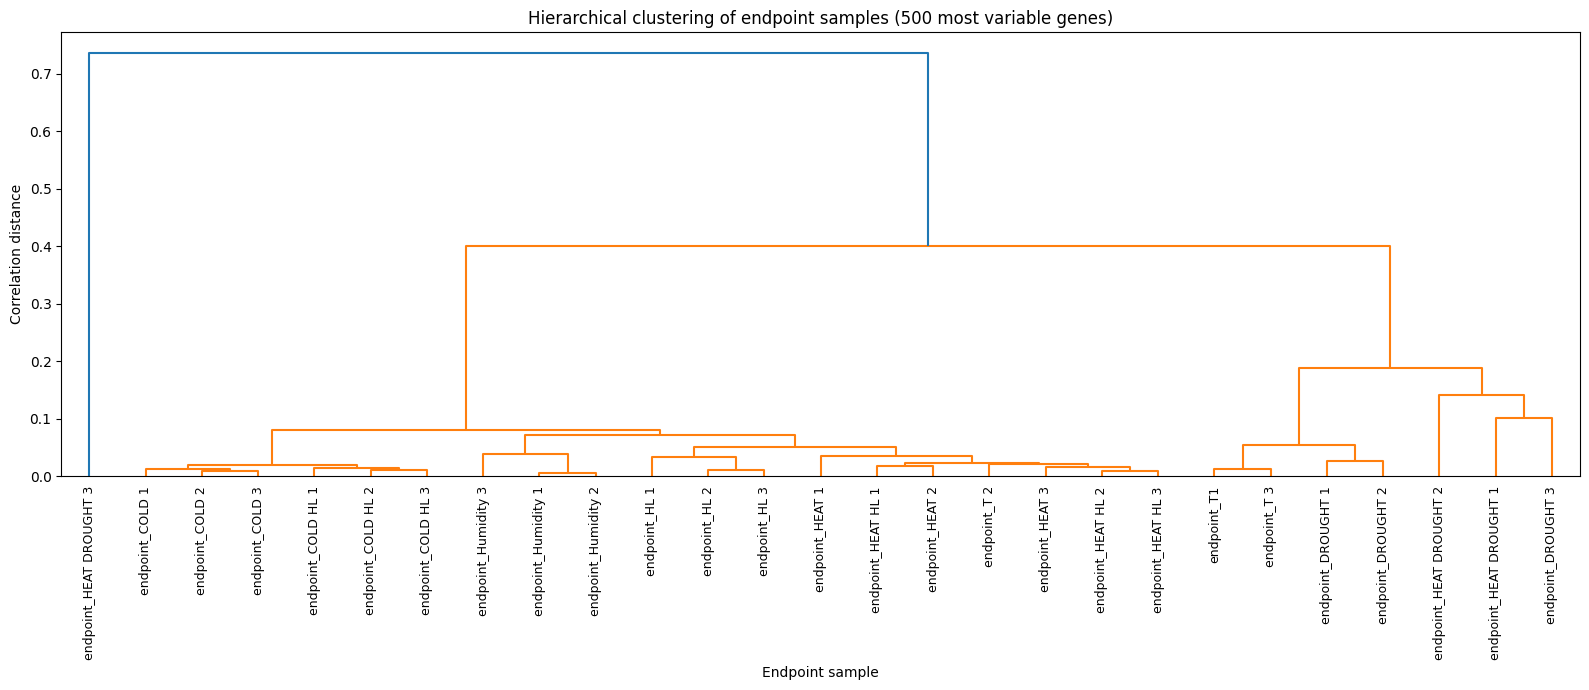

In [44]:
endpoint_input = pca_input.loc[
    sample_manifest.loc[
        sample_manifest["state"] == "endpoint",
        "matrix_column"
    ]
]

endpoint_corr_distance = pdist(
    endpoint_input,
    metric="correlation"
)

endpoint_linkage = linkage(
    endpoint_corr_distance,
    method="average"
)

plt.figure(figsize=(16, 7))

dendrogram(
    endpoint_linkage,
    labels=endpoint_input.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Hierarchical clustering of endpoint samples (500 most variable genes)")
plt.xlabel("Endpoint sample")
plt.ylabel("Correlation distance")

plt.tight_layout()
plt.show()

### **Insight —** Hierarchical clustering of transcriptomic samples

#### Unsupervised hierarchical clustering of the 500 most variable genes broadly reproduces the sample relationships observed in the correlation and PCA analyses. 

#### The heat–drought–high-light endpoint replicates `endpoint_T1` and `endpoint_T 3` cluster closely together, whereas `endpoint_T 2` falls within the broader central group containing samples from several other conditions. This provides additional evidence that `endpoint_T 2` has an expression profile that differs substantially from its two assigned biological replicates.

#### The all-sample dendrogram also shows close relationships among many control and recovery samples at small correlation distances, consistent with the broader structure observed in PCA. The biological meaning of these recovery patterns will be examined separately in downstream analyses.

#### A second prominent feature is the strong separation of the endpoint heat–drought samples. `endpoint_HEAT DROUGHT 1` and `endpoint_HEAT DROUGHT 2` form a distinct branch, while `endpoint_HEAT DROUGHT 3` is even more strongly separated from the remainder of the dataset. This suggests substantial transcriptomic differentiation associated with the heat–drought endpoint condition together with greater within-condition heterogeneity than observed for many other treatments. The dendrogram alone does not establish that replicate 3 represents a technical failure.

#### Overall, hierarchical clustering supports the existing QC assessment of `endpoint_T 2` while revealing strong treatment-associated structure among the heat–drought endpoint samples.

#### No sample is excluded on the basis of clustering alone. Instead, `endpoint_T 2` is retained as an atypical group member, while `endpoint_HEAT DROUGHT 3` is newly flagged for additional assessment before final QC decisions are made.

#### This will tell us whether the dramatic dendrogram branch reflects a genuine replicate inconsistency in the complete informative transcriptome, or whether it only emerges when we focus on the 500 most variable genes.

### Examining the samples most strongly correlated (similar overall expression) with `endpoint_HEAT DROUGHT 3`

#### The first thing we want to examine is where these appear:

#### `endpoint_HEAT DROUGHT 1`

#### `endpoint_HEAT DROUGHT 2`

#### If HD1 and HD2 are still among HD3's closest samples, that would support the idea that HD3 is an extreme member of an already distinctive heat–drought response, rather than a sample bearing no relationship to its assigned treatment.

#### If HD3's nearest neighbours instead belong almost entirely to unrelated conditions and HD1/HD2 rank much lower, that would make its within-group behavior more concerning.

In [45]:
target_hd = "endpoint_HEAT DROUGHT 3"

(
    sample_correlations_filtered[target_hd]
    .drop(target_hd)
    .sort_values(ascending=False)
    .head(15)
)

endpoint_HEAT DROUGHT 2    0.996294
endpoint_HEAT DROUGHT 1    0.994886
endpoint_DROUGHT 3         0.993952
endpoint_DROUGHT 1         0.989712
endpoint_DROUGHT 2         0.987748
endpoint_T 3               0.985813
endpoint_T1                0.985302
recovery_COLD HL 2         0.976819
endpoint_HEAT 1            0.975663
recovery_DROUGHT 2         0.973607
endpoint_HEAT 3            0.973337
endpoint_T 2               0.973227
recovery_HL 2              0.973097
recovery_HL 3              0.972822
recovery_T 3               0.972735
Name: endpoint_HEAT DROUGHT 3, dtype: float64

### **Observation -**

#### It's two closest samples are:

#### `endpoint_HEAT DROUGHT 2` :   0.996294

#### `endpoint_HEAT DROUGHT 1` :   0.994886

#### So despite looking extremely separated in the dendrogram, HD3 is still most similar to its own two biological replicates.

#### That is the key QC result

#### The next closest samples are:

#### `endpoint_DROUGHT 3`  :    0.993952

#### `endpoint_DROUGHT 1`  :    0.989712

#### `endpoint_DROUGHT 2`  :    0.987748

#### which is also biologically plausible, because heat–drought contains a drought component

#### Then come the other severe combined-stress samples:

#### `endpoint_T 3`    :         0.985813

#### `endpoint_T1`     :         0.985302

#### So the pattern is coherent rather than random.

#### What this tells us is:

#### `endpoint_HEAT DROUGHT 3` is highly unusual relative to the dataset as a whole, but it is not behaving like an isolated technical outlier.


### **Insight -** Targeted assessment of `endpoint_HEAT DROUGHT 3`

#### Although `endpoint_HEAT DROUGHT 3` forms a strongly separated branch in the hierarchical clustering, its two highest correlations are with its assigned biological replicates: approximately 0.9963 with `endpoint_HEAT DROUGHT 2` and 0.9949 with `endpoint_HEAT DROUGHT 1`. 

#### It's next closest samples are predominantly drought and other combined-stress endpoint treatments.

#### This pattern indicates that the sample remains strongly connected to its expected biological group despite its pronounced separation from much of the dataset. 

#### The large dendrogram distance therefore appears more consistent with an extreme treatment-associated transcriptional response than with an isolated technical failure. `endpoint_HEAT DROUGHT 3` is retained without an additional QC flag

In [ ]:
sample_correlations_filtered.loc[             # Directly examinining HD3's correlation with its two biological replicates
    target_hd,
    [
        "endpoint_HEAT DROUGHT 1",
        "endpoint_HEAT DROUGHT 2"
    ]
]

endpoint_HEAT DROUGHT 1    0.994886
endpoint_HEAT DROUGHT 2    0.996294
Name: endpoint_HEAT DROUGHT 3, dtype: float64

In [47]:
sample_correlations_filtered.loc[
    [
        "endpoint_HEAT DROUGHT 1",
        "endpoint_HEAT DROUGHT 2",
        "endpoint_HEAT DROUGHT 3"
    ],
    [
        "endpoint_HEAT DROUGHT 1",
        "endpoint_HEAT DROUGHT 2",
        "endpoint_HEAT DROUGHT 3"
    ]
]

,endpoint_HEAT DROUGHT 1,endpoint_HEAT DROUGHT 2,endpoint_HEAT DROUGHT 3
endpoint_HEAT DROUGHT 1,1.000000,0.998520,0.994886
endpoint_HEAT DROUGHT 2,0.998520,1.000000,0.996294
endpoint_HEAT DROUGHT 3,0.994886,0.996294,1.000000


### Correlation among the 500 most variable genes

#### Sample correlations are recalculated using only the 500 genes selected for PCA and hierarchical clustering. 

#### This allows sample relationships within the high-variance gene set to be compared directly with the patterns observed in the PCA and dendrogram.

In [48]:
variable_gene_correlations = pca_input.T.corr()

In [49]:
variable_gene_correlations.loc[
    [
        "endpoint_HEAT DROUGHT 1",
        "endpoint_HEAT DROUGHT 2",
        "endpoint_HEAT DROUGHT 3"
    ],
    [
        "endpoint_HEAT DROUGHT 1",
        "endpoint_HEAT DROUGHT 2",
        "endpoint_HEAT DROUGHT 3"
    ]
]

,endpoint_HEAT DROUGHT 1,endpoint_HEAT DROUGHT 2,endpoint_HEAT DROUGHT 3
endpoint_HEAT DROUGHT 1,1.000000,0.878568,0.659044
endpoint_HEAT DROUGHT 2,0.878568,1.000000,0.711811
endpoint_HEAT DROUGHT 3,0.659044,0.711811,1.000000


In [50]:
(
    variable_gene_correlations["endpoint_HEAT DROUGHT 3"]
    .drop("endpoint_HEAT DROUGHT 3")
    .sort_values(ascending=False)
    .head(10)
)

endpoint_HEAT DROUGHT 2    0.711811
endpoint_HEAT DROUGHT 1    0.659044
endpoint_DROUGHT 3         0.602794
endpoint_DROUGHT 1         0.528963
endpoint_DROUGHT 2         0.505705
endpoint_T1                0.460449
endpoint_T 3               0.426979
recovery_COLD HL 3         0.259184
recovery_COLD HL 1         0.256748
recovery_COLD HL 2         0.237545
Name: endpoint_HEAT DROUGHT 3, dtype: float64

### Targeted assessment of `endpoint_HEAT DROUGHT 3`

#### Across all informative genes, `endpoint_HEAT DROUGHT 3` remains very strongly correlated with its two biological replicates. 

#### However, when correlations are recalculated using the 500 most variable genes used for PCA and hierarchical clustering, these relationships decrease to approximately 0.712 with `endpoint_HEAT DROUGHT 2` and 0.659 with `endpoint_HEAT DROUGHT 1`. 

#### These two samples nevertheless remain the closest neighbours of replicate 3 within this high-variance gene set.

#### This explains why replicate 3 forms a strongly separated branch in the hierarchical clustering despite its high transcriptome-wide correlations. 

#### The differences are concentrated among genes carrying substantial variation across the experiment rather than representing a general loss of similarity across the transcriptome. 

#### The sample is therefore retained, while the increased heterogeneity among the heat–drought endpoint replicates should be considered during downstream biological analysis.

### Preparing a sample-by-gene matrix using all informative genes for a PCA robustness check

#### Examining what happens to the sample structure if PCA is performed using all informative genes rather than restricting it to the 500 most variable genes

In [52]:
all_gene_pca_input = informative_expression.T

all_gene_pca_input.shape

(57, 26118)

### Performing PCA using all informative genes as a robustness check

#### We are trying to understand, that if we use the entire informative trancriptome, what are the two main directions along which our 57 samples differ

In [53]:
pca_all = PCA(n_components=2)

all_gene_scores = pca_all.fit_transform(
    all_gene_pca_input
)

>### **Note -** scikit-learn PCA automatically centers each gene before calculating the components.
>
>#### In other words, for each gene, it considers expression relative to that gene's average across samples.
>
>#### It does not automatically scale every gene to variance 1.
>
>#### That's relevant because genes with greater variation can naturally contribute more strongly to the PCA—which is reasonable here because all genes are already represented on the same rLog-transformed expression scale.

### Storing the all-gene PCA coordinates together with their sample names.

In [ ]:
pca_all_df = pd.DataFrame({                            # creating the dataframe
    "matrix_column": all_gene_pca_input.index,
    "PC1": all_gene_scores[:, 0],
    "PC2": all_gene_scores[:, 1],
})

### Attaching sample metadata to the all-gene PCA coordinates

#### We want to attach the biological information from sample_manifest to each sample’s all-gene PCA coordinates

In [ ]:
pca_all_df = pca_all_df.merge(           # attaching the sample_manifest
    sample_manifest,
    on="matrix_column",                  # using matrix_column as matching key
    how="left"
)

In [56]:
pca_all.explained_variance_ratio_

array([0.63971673, 0.15141819])

### **Observation -**

#### Using all 26,118 informative genes:

#### PC1 = 63.97 %  PC2 = 15.14 %

#### Together:

#### PC1 + PC2 = 79.11%

#### So the first two components still capture almost 80% of the total variance across the informative transcriptome.

#### That is a strong result.



### **Insight —** PCA robustness using the complete informative transcriptome

#### PCA was repeated using all 26,118 informative genes rather than only the 500 most variable genes. 

#### PC1 explained approximately 63.97% of the variance and PC2 explained 15.14%, with the first two components together capturing approximately 79.11%. 

#### Compared with the top-500-gene PCA, variation is less concentrated in PC1 and a larger proportion is represented by PC2, showing that the broader transcriptome changes how the major sources of variation are distributed between the first two components.

#### Despite using a much larger feature set, nearly four-fifths of the total variance is still represented by PC1 and PC2. 

#### This indicates that the dataset retains a strong low-dimensional structure when the complete informative transcriptome is considered.

In [57]:
pca_all_df.shape

(57, 14)

### Visualizing sample relationships using PCA across all informative genes

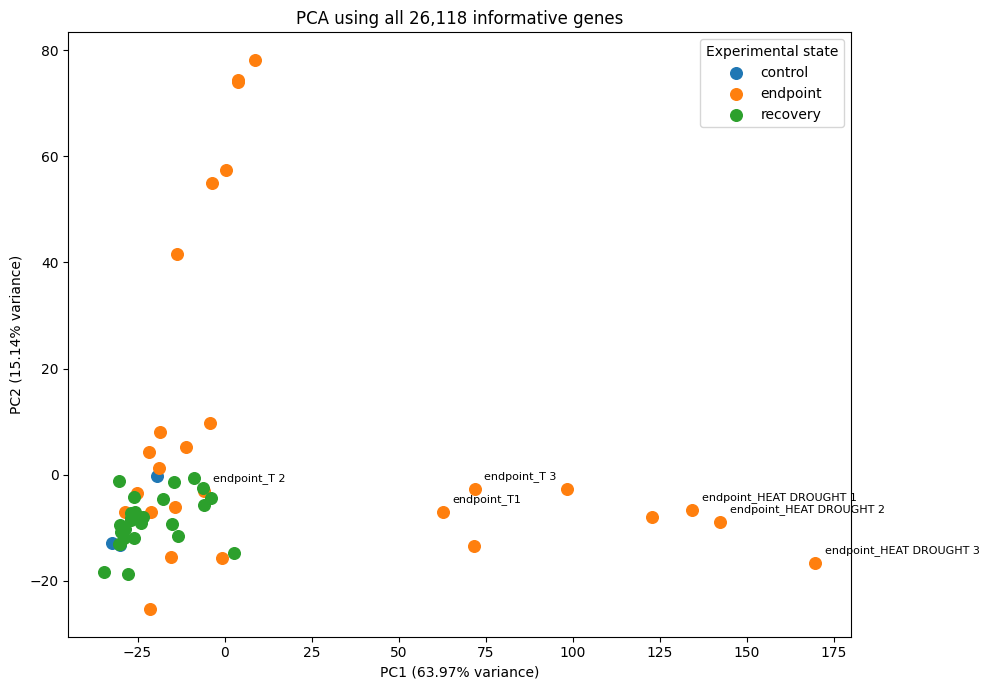

In [58]:
all_explained = (
    pca_all.explained_variance_ratio_ * 100
)

plt.figure(figsize=(10, 7))

for state, group in pca_all_df.groupby("state"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label=state,
        s=70
    )

for sample_name in [
    "endpoint_T1",
    "endpoint_T 2",
    "endpoint_T 3",
    "endpoint_HEAT DROUGHT 1",
    "endpoint_HEAT DROUGHT 2",
    "endpoint_HEAT DROUGHT 3",
]:
    target = pca_all_df[
        pca_all_df["matrix_column"] == sample_name
    ].iloc[0]

    plt.annotate(
        sample_name,
        (target["PC1"], target["PC2"]),
        xytext=(7, 7),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel(
    f"PC1 ({all_explained[0]:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({all_explained[1]:.2f}% variance)"
)

plt.title(
    "PCA using all 26,118 informative genes"
)

plt.legend(title="Experimental state")

plt.tight_layout()
plt.show()

### **Insight —** Robustness of sample structure across the complete informative transcriptome

#### PCA using all 26,118 informative genes reproduces the major sample relationships observed with the 500 most variable genes, indicating that the principal QC patterns are not driven solely by the selected high-variance feature set. 

#### In particular, `endpoint_T1` and `endpoint_T 3` remain strongly displaced in the positive PC1 direction, whereas `endpoint_T 2`remains within the dense central region of PCA space. The unusual position of `endpoint_T 2` therefore persists when the complete informative expression matrix is considered, supporting the conclusion that its global expression profile differs substantially from the other two heat–drought–high-light endpoint replicates.

#### All three endpoint heat–drought samples also remain strongly displaced along PC1. `endpoint_HEAT DROUGHT 3` is the most extreme of the three, consistent with the greater within-treatment variation identified earlier, while replicates 1 and 2 occupy the same broadly separated region. Controls and many recovery samples remain concentrated within a relatively compact region, whereas endpoint samples show considerably greater dispersion.

#### Overall, the major sample relationships are robust to using either the 500 most variable genes or the complete informative transcriptome.

### Quality Control Summary

#### Expression-level quality control was performed on the processed rlog-transformed RNA-seq matrix containing 28,775 Arabidopsis features across 57 biological samples. After excluding 2,657 genes that were invariant at zero across every sample for sample-comparison analyses, 26,118 informative genes remained. All expression columns were numerical, and no missing or infinite values were detected.

#### Sample-wise expression distributions were broadly comparable across the experiment. Median expression values ranged only from approximately 6.15 to 6.71, with similarly constrained means, standard deviations, and interquartile ranges. No sample exhibited a severe global shift, compression, or inflation of its expression distribution, providing no evidence of an obvious gross expression-level technical failure.

#### Pairwise Pearson correlations across the informative transcriptome were uniformly high, ranging from approximately 0.966 to 0.9997. Biological-replicate similarity was also strong across all 19 experimental groups. Mean within-group correlations were approximately 0.9965 or greater, and the minimum observed replicate-pair correlation remained around 0.9949.

#### A more discriminating comparison of within-group versus between-group similarity identified one notable exception: `endpoint_T 2`, representing the second endpoint replicate of the heat–drought–high-light treatment. Unlike the other 56 samples, its mean correlation with its assigned biological replicates (~0.9951) was slightly lower than its mean correlation with samples outside the group (~0.9968). Targeted nearest-neighbour analysis further showed that `endpoint_T 2` was more highly correlated with several endpoint heat and heat–high-light samples than with `endpoint_T1` and `endpoint_T 3`.

#### The discrepancy became clearer in multivariate analyses. PCA using the 500 most variable genes showed that PC1 and PC2 explained approximately 80.62% and 5.97% of the selected-gene variance, respectively. `endpoint_T1` and `endpoint_T 3` occupied a strongly displaced region along PC1, whereas `endpoint_T 2` remained within the dense central region of PCA space. Quantification in PC1–PC2 space showed that T1 and T3 were separated by approximately 7.68 PCA units, whereas T2 was approximately 48.02 units from T1 and 49.74 units from T3. Within this two-dimensional PCA representation, T2 was therefore more than six times farther from either assigned replicate than T1 and T3 were from one another.

#### Hierarchical clustering of the same 500 highly variable genes produced a consistent pattern: `endpoint_T1` and `endpoint_T 3` clustered closely within the strongly separated endpoint branch, whereas `endpoint_T 2` clustered within the broader central group. Taken together, the correlation, nearest-neighbour, PCA, PCA-distance, and hierarchical-clustering analyses consistently indicate that `endpoint_T 2` has a global expression profile that is atypical of its assigned heat–drought–high-light replicate group.

#### A second sample, `endpoint_HEAT DROUGHT 3`, showed pronounced separation in hierarchical clustering based on the 500 most variable genes. Targeted analysis showed, however, that the sample remained most similar to its expected biological group. Across all 26,118 informative genes, its two highest correlations were with the other heat–drought replicates. Within the 500 highly variable genes, those same two replicates remained its nearest neighbours, followed by drought endpoint samples. The sample therefore appears to show greater within-treatment transcriptional variation, particularly among highly variable genes, rather than evidence of gross technical failure or clear sample misassignment.

#### PCA was subsequently repeated using all 26,118 informative genes as a robustness check. PC1 and PC2 explained approximately 63.97% and 15.14% of total variance, respectively, together accounting for approximately 79.11%. The major sample relationships persisted: `endpoint_T1` and `endpoint_T 3` remained strongly displaced from `endpoint_T 2`, while all three endpoint heat–drought samples remained strongly displaced in the positive PC1 direction. This indicates that the principal QC observations are not driven solely by selection of the 500 most variable genes.

#### The broader sample structure also showed biologically coherent organization. Controls occupied a compact region of PCA space, many recovery samples occurred nearby or within the broader central region, and endpoint samples showed substantially greater dispersion. These patterns are compatible with treatment-associated changes in gene expression and possible movement of some recovery samples toward control-like profiles, but the biological meaning of recovery dynamics will be evaluated formally in subsequent analyses rather than inferred from QC alone.

#### Final expression-level QC decision: all 57 samples are retained. `endpoint_T 2` is formally flagged as an atypical biological replicate requiring downstream sensitivity and interpretation caution. `endpoint_HEAT DROUGHT 3` is retained as a sample showing greater within-treatment variability while remaining most similar to the other heat–drought replicates. No other major expression-level sample anomaly was detected.

#### These conclusions apply specifically to the processed rlog expression matrix. Because raw sequencing reads and sequencing-level QC metrics were not analyzed in this notebook, this assessment does not evaluate FASTQ quality, adapter contamination, read depth, mapping efficiency, duplication rate, library complexity, or other raw-sequencing quality measures.